# Nasdaq Black Swan - Date si Feature Engineering
**Ticker:** ^IXIC (Nasdaq Composite)  
**Diferente fata de SP500 V4:**
- Threshold criza: -10% (vs -7% SP500)
- V-shape: +8% in 60 zile (vs +5%)
- L-shape: -3% in 60 zile (vs -2%)
- Evenimente extinse si specifice Nasdaq

## 1. Import Librarii

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)

print('Librarii incarcate.')

Librarii incarcate.


## 2. Definitia Evenimentelor

Evenimente extinse si specifice Nasdaq fata de SP500 V4.

In [2]:
EVENTS = [
    # Grey Swan - extinse pentru Nasdaq
    {'name': 'Dotcom Crash',           'start': '1999-01-01', 'end': '2002-10-31', 'category': 'Grey Swan'},
    {'name': 'Global Financial Crisis','start': '2008-01-01', 'end': '2009-06-30', 'category': 'Grey Swan'},
    {'name': 'European Debt Crisis',   'start': '2011-04-01', 'end': '2011-12-31', 'category': 'Grey Swan'},
    {'name': 'Taper Tantrum',          'start': '2013-04-01', 'end': '2013-10-31', 'category': 'Grey Swan'},
    {'name': 'China Devaluation',      'start': '2015-06-01', 'end': '2016-02-28', 'category': 'Grey Swan'},
    {'name': 'Fed Rate Hikes 2022',    'start': '2021-11-01', 'end': '2022-12-31', 'category': 'Grey Swan'},
    {'name': 'Liberation Day Tariffs', 'start': '2025-02-01', 'end': '2025-08-01', 'category': 'Grey Swan'},

    # Black Swan
    {'name': '9/11',                   'start': '2001-07-01', 'end': '2001-12-31', 'category': 'Black Swan'},
    {'name': 'Flash Crash',            'start': '2010-04-01', 'end': '2010-08-31', 'category': 'Black Swan'},
    {'name': 'COVID Crash',            'start': '2020-01-15', 'end': '2020-08-31', 'category': 'Black Swan'},

    # Specifice Nasdaq
    {'name': 'Crypto-Tech Selloff',    'start': '2021-11-01', 'end': '2022-12-31', 'category': 'Grey Swan'},
    {'name': 'AI Valuation Reset',     'start': '2023-07-01', 'end': '2023-10-31', 'category': 'Grey Swan'},
]

# Eliminam duplicate de nume (Fed Rate Hikes si Crypto-Tech Selloff
# acopera aceeasi perioada, pastram unul)
seen   = set()
unique = []
for e in EVENTS:
    key = e['start'] + e['end']
    if key not in seen:
        seen.add(key)
        unique.append(e)
EVENTS = unique

print('Evenimente finale:', len(EVENTS))
for e in EVENTS:
    print(' ', e['category'].ljust(12), e['name'].ljust(30), e['start'], '->', e['end'])

Evenimente finale: 11
  Grey Swan    Dotcom Crash                   1999-01-01 -> 2002-10-31
  Grey Swan    Global Financial Crisis        2008-01-01 -> 2009-06-30
  Grey Swan    European Debt Crisis           2011-04-01 -> 2011-12-31
  Grey Swan    Taper Tantrum                  2013-04-01 -> 2013-10-31
  Grey Swan    China Devaluation              2015-06-01 -> 2016-02-28
  Grey Swan    Fed Rate Hikes 2022            2021-11-01 -> 2022-12-31
  Grey Swan    Liberation Day Tariffs         2025-02-01 -> 2025-08-01
  Black Swan   9/11                           2001-07-01 -> 2001-12-31
  Black Swan   Flash Crash                    2010-04-01 -> 2010-08-31
  Black Swan   COVID Crash                    2020-01-15 -> 2020-08-31
  Grey Swan    AI Valuation Reset             2023-07-01 -> 2023-10-31


## 3. Descarcare Date

In [3]:
nasdaq_raw = yf.download('^IXIC', start='1998-01-01', end='2025-09-01', auto_adjust=True)
nasdaq_raw = nasdaq_raw[['Close', 'Volume']].copy()
nasdaq_raw.columns = ['NASDAQ_Close', 'NASDAQ_Volume']

vix_raw = yf.download('^VIX', start='1998-01-01', end='2025-09-01', auto_adjust=True)
vix_raw = vix_raw[['Close']].copy()
vix_raw.columns = ['VIX_raw']

daily = nasdaq_raw.join(vix_raw, how='left')
daily.index = pd.to_datetime(daily.index)

print('Date descarcate:', daily.index[0].date(), '->', daily.index[-1].date())
print('Total zile:', len(daily))
daily.tail(3)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Date descarcate: 1998-01-02 -> 2025-08-29
Total zile: 6958


,NASDAQ_Close,NASDAQ_Volume,VIX_raw
Date,,,
2025-08-27,21590.140625,8040510000,14.85
2025-08-28,21705.160156,7807080000,14.43
2025-08-29,21455.550781,7715430000,15.36


## 4. Feature Engineering pe Date Zilnice

In [4]:
df = daily.copy()

# Indicatori de trend
df['MA50']             = df['NASDAQ_Close'].rolling(50).mean()
df['MA200']            = df['NASDAQ_Close'].rolling(200).mean()
df['Dist_MA50']        = (df['NASDAQ_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200']       = (df['NASDAQ_Close'] - df['MA200']) / df['MA200']
df['Dist_52w_High']    = (df['NASDAQ_Close'] - df['NASDAQ_Close'].rolling(252).max()) / df['NASDAQ_Close'].rolling(252).max()
df['Return_1d']        = df['NASDAQ_Close'].pct_change()
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)
df['Local_Min_20d']    = df['NASDAQ_Close'].rolling(20).min()
df['Dist_Local_Min']   = (df['NASDAQ_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']
df['VIX_MA60']         = df['VIX_raw'].rolling(60).mean()
df['VIX_Ratio']        = df['VIX_raw'] / df['VIX_MA60']

def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['NASDAQ_Close'])

def rolling_slope(series, window):
    slopes = [np.nan] * len(series)
    vals   = series.values
    x      = np.arange(window)
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

df['VIX_Trend_20d']      = rolling_slope(df['VIX_raw'], 20)
df['NASDAQ_Trend_20d']   = rolling_slope(df['NASDAQ_Close'], 20)

# Forward return pe 60 de zile + label binar
V_THRESHOLD  = 0.08    # +8% in 60 zile = V-shape pentru Nasdaq
FORWARD_DAYS = 60

df['Forward_Return_60d'] = df['NASDAQ_Close'].shift(-FORWARD_DAYS) / df['NASDAQ_Close'] - 1
df['label_daily']        = (df['Forward_Return_60d'] > V_THRESHOLD).astype(float)

print('Features zilnice calculate.')
print('V-shape threshold: +' + str(int(V_THRESHOLD*100)) + '% in', FORWARD_DAYS, 'zile lucratoare')

Features zilnice calculate.
V-shape threshold: +8% in 60 zile lucratoare


## 5. Agregare Saptamanala

In [5]:
agg_rules = {
    'NASDAQ_Close'    : 'last',
    'NASDAQ_Volume'   : 'sum',
    'VIX_raw'         : 'mean',
    'Dist_MA50'       : 'last',
    'Dist_MA200'      : 'last',
    'Dist_52w_High'   : 'last',
    'RSI'             : 'last',
    'Dist_Local_Min'  : 'last',
    'VIX_Ratio'       : 'mean',
    'VIX_Trend_20d'   : 'mean',
    'NASDAQ_Trend_20d': 'last',
    'Realized_Vol_10d': 'mean',
    'label_daily'     : lambda x: x.mode()[0] if len(x) > 0 else np.nan
}

weekly = df.resample('W-FRI').agg(agg_rules)
weekly = weekly.rename(columns={'VIX_raw': 'VIX', 'NASDAQ_Trend_20d': 'SP500_Trend_20d'})

weekly['Return_1w']    = weekly['NASDAQ_Close'].pct_change()
weekly['Return_4w']    = weekly['NASDAQ_Close'].pct_change(4)
weekly['Volume_Ratio'] = weekly['NASDAQ_Volume'] / weekly['NASDAQ_Volume'].rolling(8).mean()
weekly['label']        = weekly['label_daily'].astype(int)

weekly = weekly.loc[:, ~weekly.columns.duplicated()]
weekly.dropna(subset=['Return_1w', 'label'], inplace=True)

print('Date saptamanale:')
print('Total saptamani:', len(weekly))
print('Perioada:', weekly.index[0].date(), '->', weekly.index[-1].date())

Date saptamanale:
Total saptamani: 1443
Perioada: 1998-01-09 -> 2025-08-29


## 6. Constructie Dataset cu Ferestre per Eveniment

In [6]:
feature_cols = [
    'Return_1w', 'Return_4w', 'Dist_MA50', 'Dist_MA200',
    'Dist_52w_High', 'Dist_Local_Min',
    'VIX', 'VIX_Ratio', 'VIX_Trend_20d',
    'Realized_Vol_10d', 'Volume_Ratio',
    'RSI', 'SP500_Trend_20d',
    'Phase'
]

all_windows = []

for event in EVENTS:
    mask   = (weekly.index >= event['start']) & (weekly.index <= event['end'])
    window = weekly.loc[mask].copy()

    if len(window) == 0:
        print('ATENTIE: Nu s-au gasit date pentru', event['name'])
        continue

    n      = len(window)
    phases = [1 if i <= 6 else (2 if i <= 18 else 3) for i in range(n)]
    window['Phase']         = phases
    window['event_name']    = event['name']
    window['category']      = event['category']
    window['week_relative'] = range(n)

    all_windows.append(window)
    print(event['name'].ljust(30), ':', n, 'saptamani | V-shape:', (window['label']==1).sum())

dataset = pd.concat(all_windows)
dataset = dataset.dropna(subset=feature_cols + ['label'])

print('\nDataset final:', len(dataset), 'saptamani')
counts = dataset['label'].value_counts()
print('Non-V (0):   ', counts.get(0, 0), '(' + str(round(counts.get(0,0)/len(dataset)*100, 1)) + '%)')
print('V-shape (1): ', counts.get(1, 0), '(' + str(round(counts.get(1,0)/len(dataset)*100, 1)) + '%)')
print('\nDistributie per eveniment:')
pivot = dataset.groupby(['event_name', 'label']).size().unstack(fill_value=0)
pivot.columns = ['Non-V (0)', 'V-shape (1)']
pivot['% V-shape'] = (pivot['V-shape (1)'] / (pivot['Non-V (0)'] + pivot['V-shape (1)']) * 100).round(1)
print(pivot)

Dotcom Crash                   : 200 saptamani | V-shape: 63
Global Financial Crisis        : 78 saptamani | V-shape: 25
European Debt Crisis           : 40 saptamani | V-shape: 8
Taper Tantrum                  : 30 saptamani | V-shape: 16
China Devaluation              : 39 saptamani | V-shape: 5
Fed Rate Hikes 2022            : 61 saptamani | V-shape: 8
Liberation Day Tariffs         : 26 saptamani | V-shape: 13
9/11                           : 26 saptamani | V-shape: 9
Flash Crash                    : 22 saptamani | V-shape: 8
COVID Crash                    : 33 saptamani | V-shape: 19
AI Valuation Reset             : 17 saptamani | V-shape: 6

Dataset final: 572 saptamani
Non-V (0):    392 (68.5%)
V-shape (1):  180 (31.5%)

Distributie per eveniment:
                         Non-V (0)  V-shape (1)  % V-shape
event_name                                                
9/11                            17            9       34.6
AI Valuation Reset              11            6       35.3

## 7. Vizualizare Labeluri pe Nasdaq

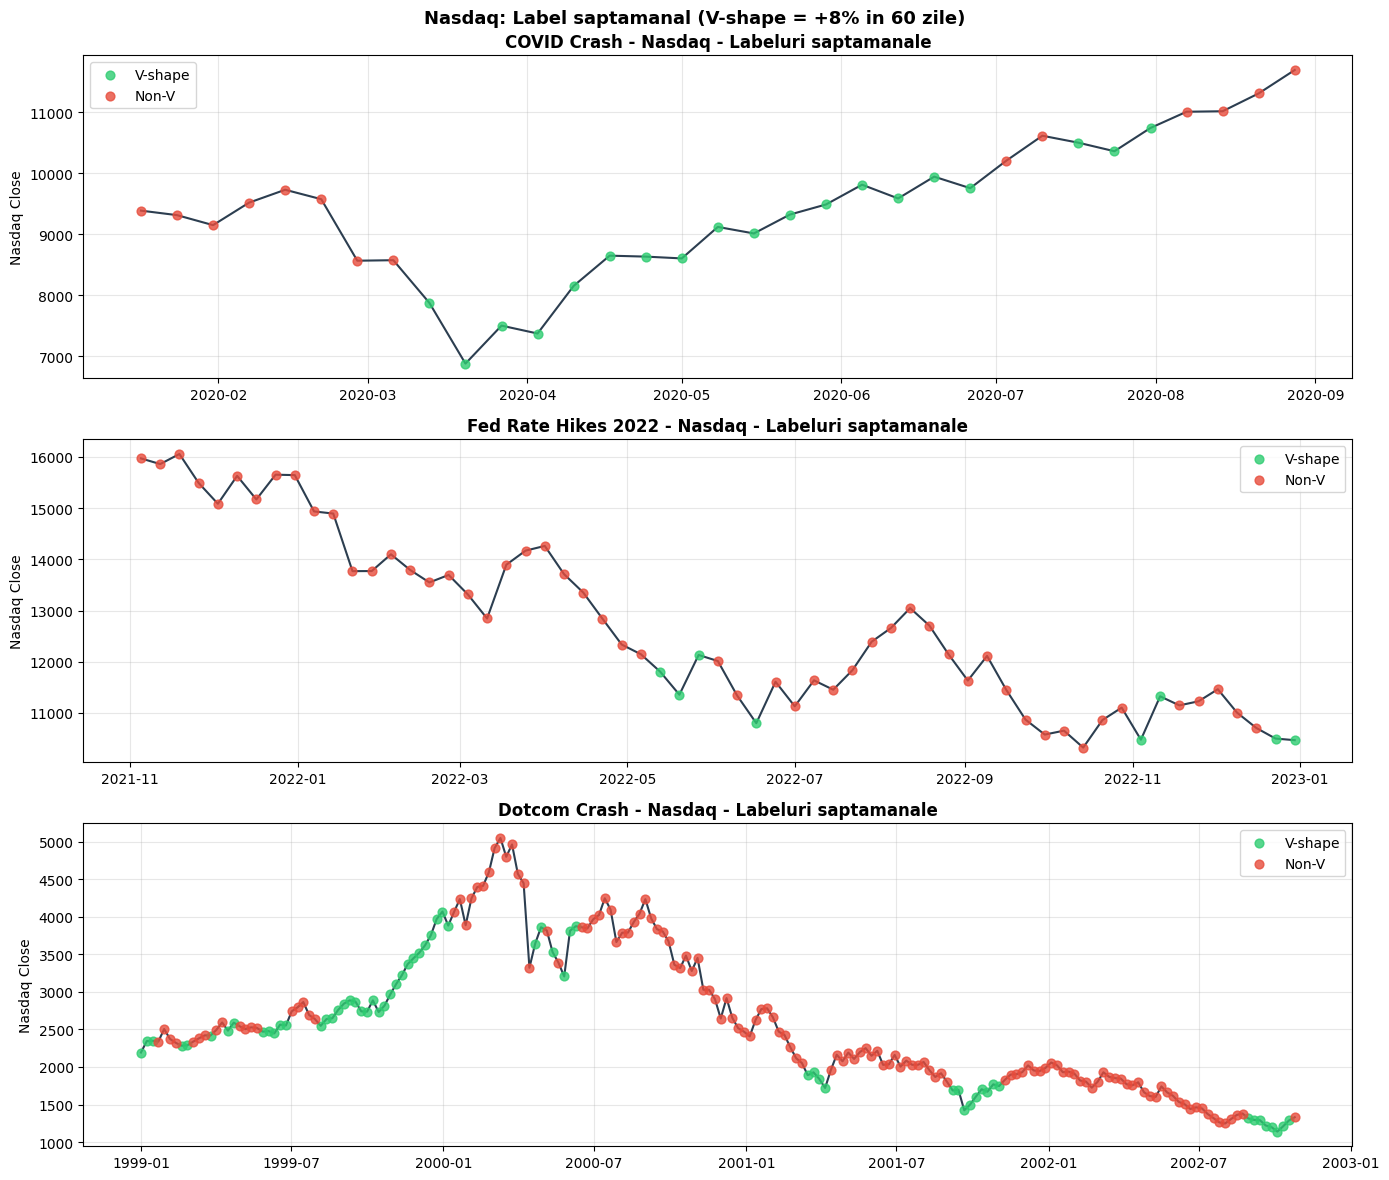

Salvat: plots/nasdaq_labels.png


In [7]:
events_to_plot = ['COVID Crash', 'Fed Rate Hikes 2022', 'Dotcom Crash']
colors_map     = {1: '#2ecc71', 0: '#e74c3c'}
labels_map     = {1: 'V-shape', 0: 'Non-V'}

fig, axes = plt.subplots(len(events_to_plot), 1, figsize=(14, 4 * len(events_to_plot)))

for ax, event_name in zip(axes, events_to_plot):
    ev     = dataset[dataset['event_name'] == event_name]
    prices = ev['NASDAQ_Close']

    ax.plot(prices.index, prices.values, color='#2c3e50', linewidth=1.5, zorder=3)

    for lbl, color in colors_map.items():
        mask = ev['label'] == lbl
        if mask.any():
            ax.scatter(ev.index[mask], prices[mask],
                      color=color, s=40, alpha=0.8, label=labels_map[lbl], zorder=4)

    ax.set_title(event_name + ' - Nasdaq - Labeluri saptamanale', fontsize=12, fontweight='bold')
    ax.set_ylabel('Nasdaq Close')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Nasdaq: Label saptamanal (V-shape = +8% in 60 zile)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/nasdaq_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/nasdaq_labels.png')

## 8. Train / Test Split

In [8]:
TRAIN_EVENTS = [
    'Global Financial Crisis', 'European Debt Crisis',
    'Taper Tantrum', 'China Devaluation',
    '9/11', 'Flash Crash', 'AI Valuation Reset'
]
TEST_EVENTS = [
    'Fed Rate Hikes 2022', 'COVID Crash', 'Liberation Day Tariffs'
]

# Dotcom spart: ultimele 40 saptamani -> test
dotcom_all   = dataset[dataset['event_name'] == 'Dotcom Crash']
dotcom_train = dotcom_all.iloc[:-40]
dotcom_test  = dotcom_all.iloc[-40:]

train_df = pd.concat([dotcom_train, dataset[dataset['event_name'].isin(TRAIN_EVENTS)]])
test_df  = pd.concat([dotcom_test,  dataset[dataset['event_name'].isin(TEST_EVENTS)]])

train_df = train_df.dropna(subset=feature_cols)
test_df  = test_df.dropna(subset=feature_cols)

print('Train:', len(train_df), 'saptamani')
print('Test: ', len(test_df),  'saptamani')

for split_name, split in [('Train', train_df), ('Test', test_df)]:
    c = split['label'].value_counts()
    print('\nDistributie', split_name + ':')
    print('  Non-V (0):  ', c.get(0, 0))
    print('  V-shape (1):', c.get(1, 0))

Train: 412 saptamani
Test:  160 saptamani

Distributie Train:
  Non-V (0):   280
  V-shape (1): 132

Distributie Test:
  Non-V (0):   112
  V-shape (1): 48


## 9. Salvare Dataset

In [9]:
dataset.to_csv('nasdaq_dataset.csv')
train_df.to_csv('nasdaq_train.csv')
test_df.to_csv('nasdaq_test.csv')

with open('nasdaq_feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

meta_data = {
    'ticker'       : '^IXIC',
    'v_threshold'  : V_THRESHOLD,
    'forward_days' : FORWARD_DAYS,
    'frequency'    : 'weekly',
    'feature_cols' : feature_cols
}
with open('nasdaq_data_meta.json', 'w') as f:
    json.dump(meta_data, f, indent=2)

print('Fisiere salvate:')
print('  nasdaq_dataset.csv ->', len(dataset), 'saptamani')
print('  nasdaq_train.csv   ->', len(train_df), 'saptamani')
print('  nasdaq_test.csv    ->', len(test_df), 'saptamani')
print('  nasdaq_feature_cols.json')
print('  nasdaq_data_meta.json')
print('\nGata pentru nasdaq_modeling.ipynb')

Fisiere salvate:
  nasdaq_dataset.csv -> 572 saptamani
  nasdaq_train.csv   -> 412 saptamani
  nasdaq_test.csv    -> 160 saptamani
  nasdaq_feature_cols.json
  nasdaq_data_meta.json

Gata pentru nasdaq_modeling.ipynb
